# Manufacturing Cell OEE Performance Loss Detection
## Anomaly Detection on Real PLC Data (Siemens S7 + Beckhoff)
### A CRISP-DM Approach

---

| | |
|---|---|
| **Project**     | Mini Project 1 — B5: OEE Performance Loss Detection |
| **Dataset**      | Real PLC data — Siemens S7 & Beckhoff controllers (8.5 min manufacturing cell recording) |
| **Methodology**  | CRISP-DM |
| **Supervised by**| Prof. Felix Georg Müller |
| **Created by**   | Sravanthi |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker


In [2]:
# =============================================================================
# 2.1  LOAD DATA
# =============================================================================
import os

BASE = os.path.join(os.path.expanduser("~"), "my_project", "Sem2_B5",
                    "B5_Group_4-main", "Example batch-Dataset")

df_s = pd.read_csv(
    os.path.join(BASE, "Beispieldatensatz Siemens S7 SPS.csv"),
    sep=";", engine="python",
)
df_b = pd.read_csv(
    os.path.join(BASE, "Beispieldatensatz Beckhoff SPS.csv"),
    sep=";", engine="python",
)

print("Raw shapes:")
print(f"  Siemens  : {df_s.shape}")
print(f"  Beckhoff : {df_b.shape}")

Raw shapes:
  Siemens  : (6283, 144)
  Beckhoff : (5197, 55)


In [3]:

# =============================================================================
# 2.2  CLEAN UP
# =============================================================================

# Drop trailing empty columns (CSV export artefact)
df_s = df_s.drop(columns=[c for c in df_s.columns if "Unnamed" in c])
df_b = df_b.drop(columns=[c for c in df_b.columns if "Unnamed" in c])

# Parse timestamps (Unix milliseconds → datetime)
df_s["timestamp"] = pd.to_datetime(
    pd.to_numeric(df_s["timestamp"], errors="coerce"), unit="ms"
)
df_b["timestamp"] = pd.to_datetime(
    pd.to_numeric(df_b["timestamp"], errors="coerce"), unit="ms"
)

# Sort by time
df_s = df_s.sort_values("timestamp").reset_index(drop=True)
df_b = df_b.sort_values("timestamp").reset_index(drop=True)

print("\nAfter cleanup:")
print(f"  Siemens  : {df_s.shape}")
print(f"  Beckhoff : {df_b.shape}")





After cleanup:
  Siemens  : (6283, 143)
  Beckhoff : (5197, 54)


In [4]:
# =============================================================================
# 2.3  BASIC INSPECTION
# =============================================================================

def inspect(df, name):
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Rows x Cols    : {df.shape}")
    print(f"  Time start     : {df['timestamp'].min()}")
    print(f"  Time end       : {df['timestamp'].max()}")
    print(f"  Duration       : {df['timestamp'].max() - df['timestamp'].min()}")
    print(f"  Median interval: {df['timestamp'].diff().median()}")

    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if missing.empty:
        print("  Missing values : none")
    else:
        print(f"  Missing values : {len(missing)} columns affected")
        print(missing.to_string())

    # Column type breakdown
    bool_like = df.isin([0, 1, True, False]).all().sum()
    print(f"  Boolean-like cols : {bool_like}")
    print(f"  Numeric cols      : {df.select_dtypes('number').shape[1]}")

inspect(df_s, "Siemens S7")
inspect(df_b, "Beckhoff")





  Siemens S7
  Rows x Cols    : (6283, 143)
  Time start     : 2019-09-26 18:21:14.515000
  Time end       : 2019-09-26 18:29:40.239000
  Duration       : 0 days 00:08:25.724000
  Median interval: 0 days 00:00:00.076000
  Missing values : 118 columns affected
M34.4     1
M24.7     1
M25.3     1
M25.4     1
M38.0     1
M38.1     1
A0.1      1
A0.0      1
M1.0      1
M1.1      1
C0        1
EW288     1
MW16      1
M0.4      1
M1.2      1
MW12      1
MW14      1
MW18      1
M1.5      1
M2.4      1
A0.2      1
A0.3      1
A0.4      1
M2.7      1
M2.6      1
M0.2      1
M0.6      1
C1        1
M0.7      1
M1.6      1
C2        1
M2.0      1
M2.1      1
M2.2      1
M2.3      1
M3.0      1
M3.1      1
A0.5      1
A0.6      1
A0.7      1
A1.0      1
A1.1      1
A1.2      1
A1.3      1
A1.4      1
A1.5      1
A1.6      1
A1.7      1
A4.0      1
A4.1      1
A4.2      1
C4        1
MW20      1
M4.1      1
M3.6      1
M4.3      1
M3.2      1
M3.3      1
M3.4      1
M4.2      1
M3.5      1
M4.0   

In [5]:
# =============================================================================
# 2.4  UNDERSTAND COLUMN GROUPS
# =============================================================================

# Siemens columns grouped by type (from PLC variable list)
siemens_inputs  = [c for c in df_s.columns if c.startswith("E")]
siemens_outputs = [c for c in df_s.columns if c.startswith("A")]
siemens_memory  = [c for c in df_s.columns if c.startswith("M")]
siemens_numeric = [c for c in df_s.columns if c.startswith("MW")
                   or c.startswith("MD") or c.startswith("EW")]

print("\nSiemens column groups:")
print(f"  Inputs  (E*) : {len(siemens_inputs)}  — sensors, light barriers, limit switches")
print(f"  Outputs (A*) : {len(siemens_outputs)} — motors, actuators, compressors")
print(f"  Memory  (M*) : {len(siemens_memory)}  — internal logic bits")
print(f"  Numeric (MW/MD/EW): {len(siemens_numeric)} — counters, timers, values")

beckhoff_inputs  = [c for c in df_b.columns if ".I" in c]
beckhoff_outputs = [c for c in df_b.columns if ".Q" in c]
beckhoff_encoders= [c for c in df_b.columns if ".B" in c or ".A" in c]

print("\nBeckhoff column groups:")
print(f"  Inputs   (.I*): {len(beckhoff_inputs)}  — sensors, ref switches, light barriers")
print(f"  Outputs  (.Q*): {len(beckhoff_outputs)} — motors, drives")
print(f"  Encoders (.B/.A): {len(beckhoff_encoders)} — position feedback")





Siemens column groups:
  Inputs  (E*) : 24  — sensors, light barriers, limit switches
  Outputs (A*) : 31 — motors, actuators, compressors
  Memory  (M*) : 82  — internal logic bits
  Numeric (MW/MD/EW): 12 — counters, timers, values

Beckhoff column groups:
  Inputs   (.I*): 9  — sensors, ref switches, light barriers
  Outputs  (.Q*): 22 — motors, drives
  Encoders (.B/.A): 12 — position feedback


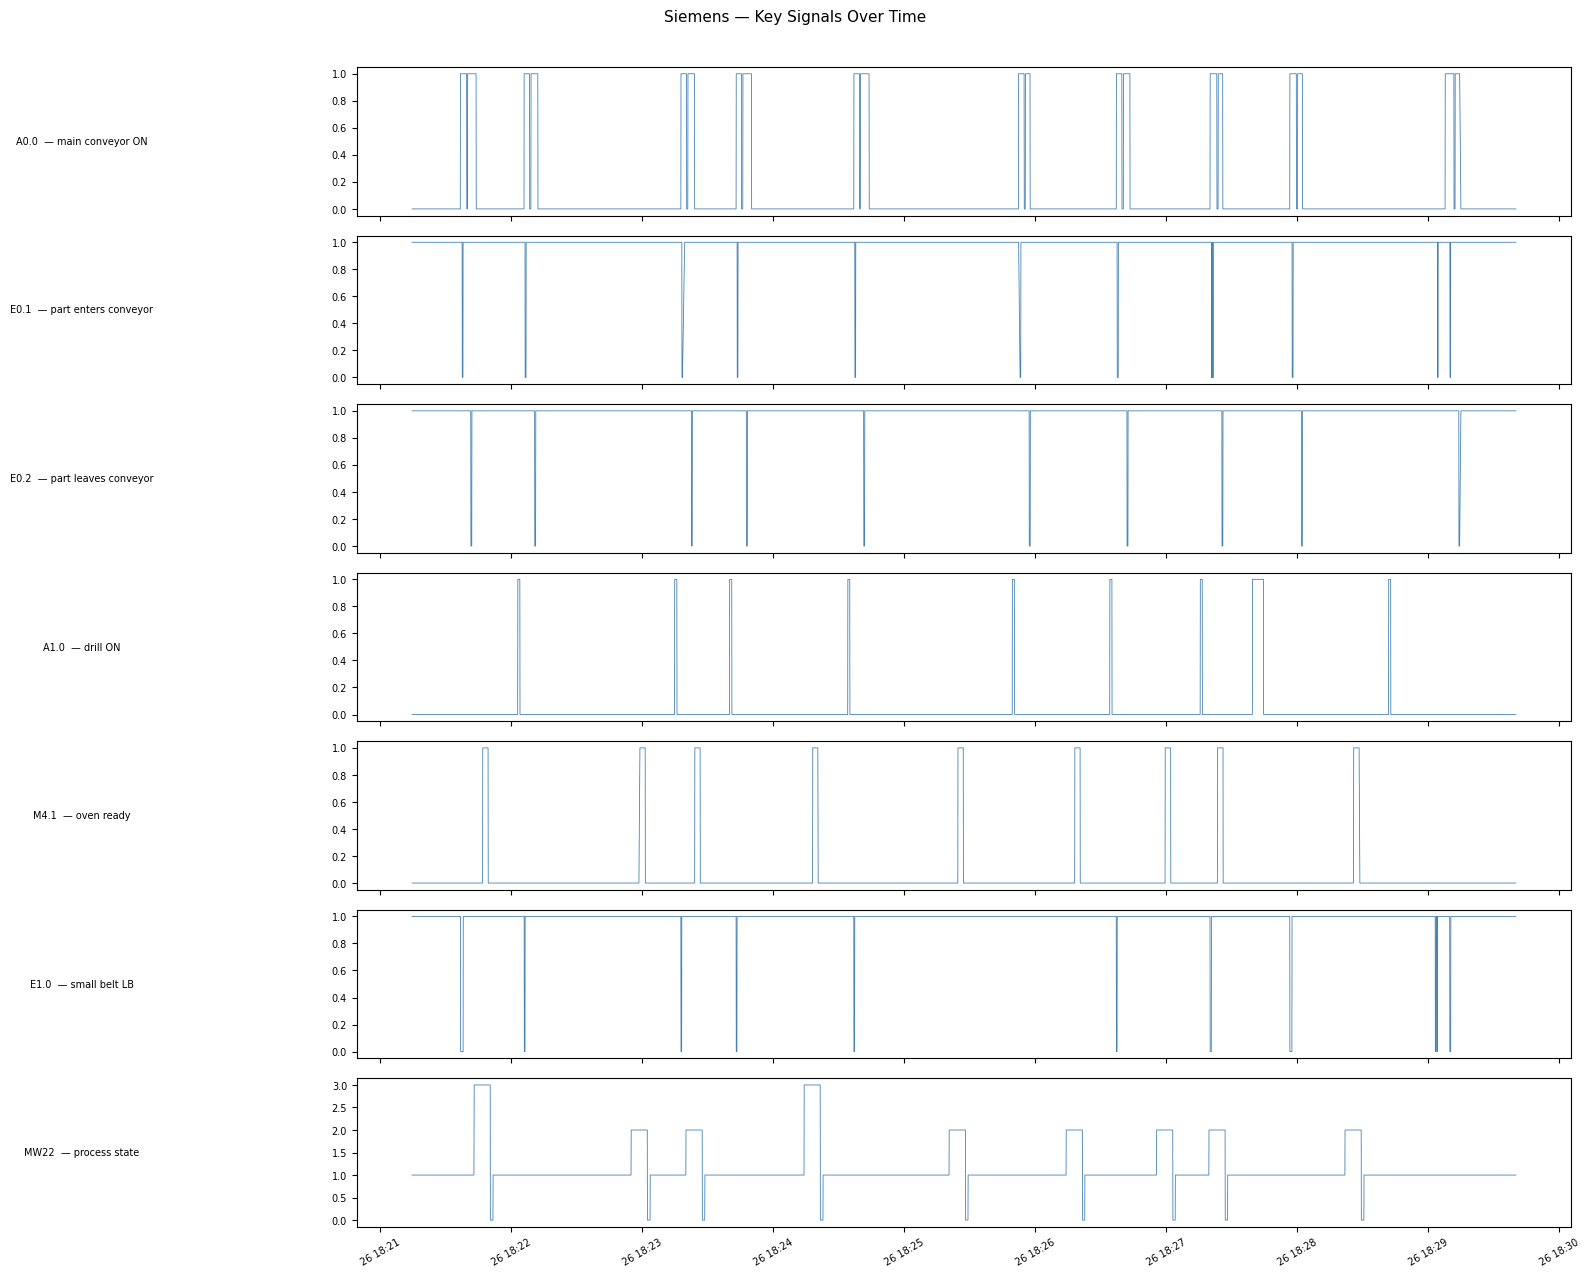

Saved: siemens__key_signals_over_time.png


In [6]:
# =============================================================================
# 2.5  VISUALISE KEY SIGNALS
# =============================================================================

# Pick one representative signal from each physical subsystem
# to get a feel for the raw data shape

plot_signals_siemens = {
    "A0.0  — main conveyor ON":        "A0.0",
    "E0.1  — part enters conveyor":    "E0.1",
    "E0.2  — part leaves conveyor":    "E0.2",
    "A1.0  — drill ON":                "A1.0",
    "M4.1  — oven ready":              "M4.1",
    "E1.0  — small belt LB":           "E1.0",
    "MW22  — process state":           "MW22",
}

plot_signals_beckhoff = {
    "WH.I2 — LB inside warehouse":     "WH.I2_Light_barrier_inside",
    "WH.I3 — LB outside warehouse":    "WH.I3_Light_barrier_outside",
    "VG.atHome — gripper at home":     "VG.atHome",
    "VG.B1 — vertical encoder":        "VG.B1_encoder_vertical_impulse1",
    "WH.Q3 — move towards rack":       "WH.Q3_horizontal_towards_rack",
}

def plot_signals(df, signal_dict, title):
    n = len(signal_dict)
    fig, axes = plt.subplots(n, 1, figsize=(16, n * 1.8), sharex=True)
    fig.suptitle(title, fontsize=11, y=1.01)
    for ax, (label, col) in zip(axes, signal_dict.items()):
        if col in df.columns:
            ax.plot(df["timestamp"], df[col].astype(float),
                    linewidth=0.6, color="steelblue")
        else:
            ax.text(0.5, 0.5, "column not found",
                    transform=ax.transAxes, ha="center")
        ax.set_ylabel(label, fontsize=7, rotation=0,
                      labelpad=180, va="center")
        ax.tick_params(axis="y", labelsize=7)
    axes[-1].tick_params(axis="x", labelsize=7, rotation=30)
    plt.tight_layout()
    fname = title.lower().replace(" ", "_").replace("—", "").replace(
        "/", "") + ".png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

plot_signals(df_s, plot_signals_siemens,  "Siemens — Key Signals Over Time")




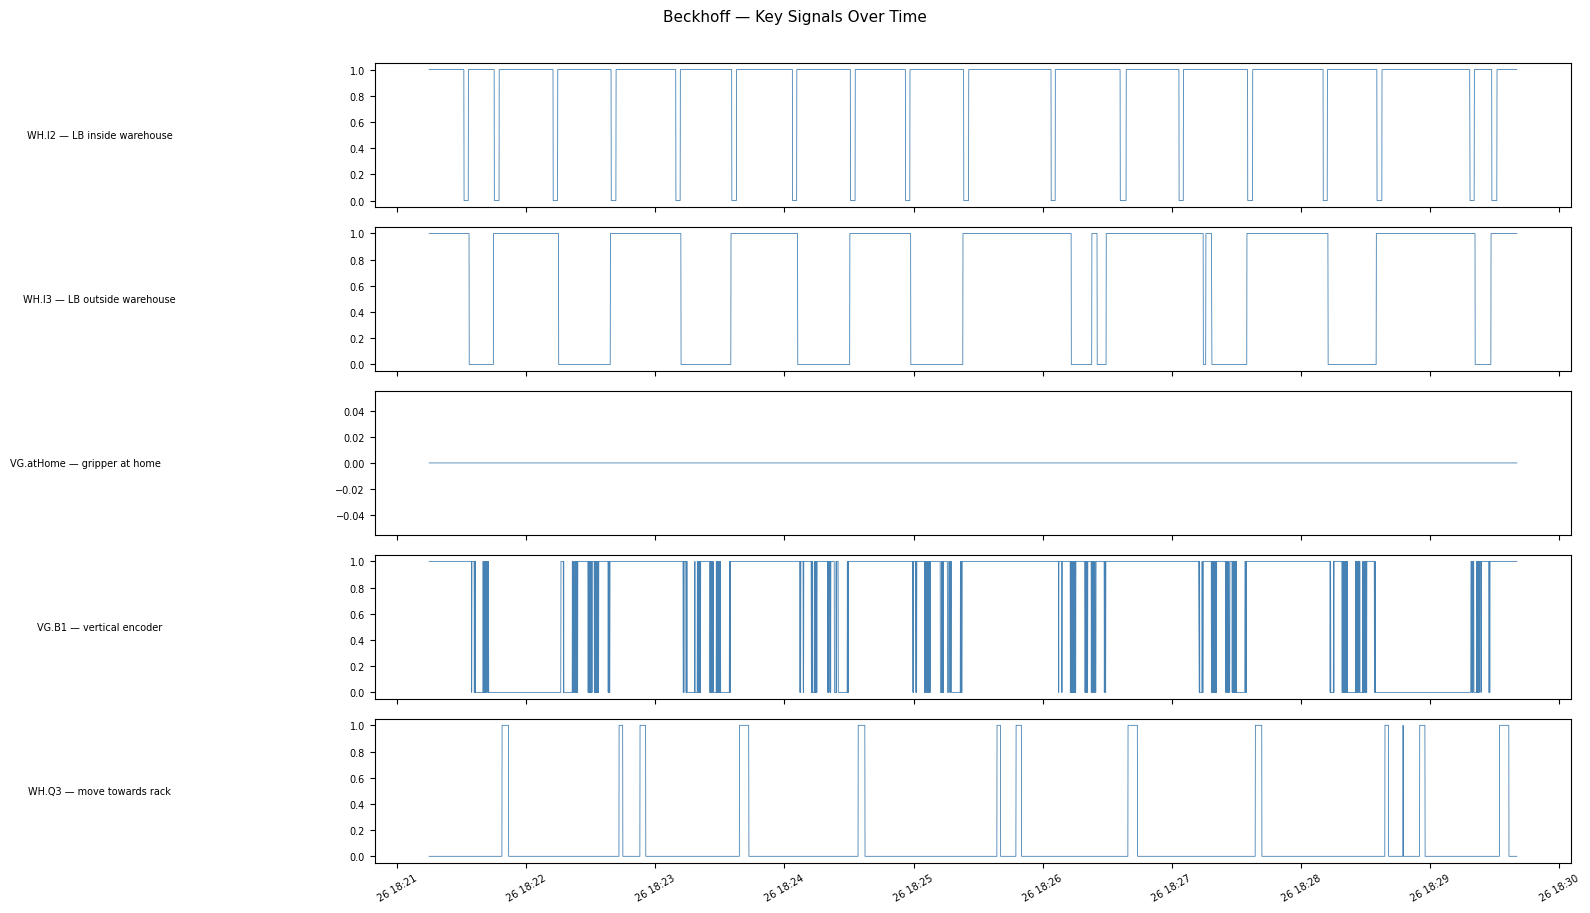

Saved: beckhoff__key_signals_over_time.png


In [7]:
plot_signals(df_b, plot_signals_beckhoff, "Beckhoff — Key Signals Over Time")


In [8]:
# =============================================================================
# 3.  CYCLE SEGMENTATION  +  RESAMPLING EXPERIMENTS
# =============================================================================


# -----------------------------------------------------------------------------
# 3.1  CYCLE SEGMENTATION VIA MW22
# — MW22 is the PLC state register: 0 = idle/reset, 1-3 = active phases
# — A rising edge from 0 → nonzero marks the start of a new cycle
# — We assign a unique cycle_id to every row
# -----------------------------------------------------------------------------

def label_cycles(df, state_col="MW22"):
    df = df.copy()
    s = df[state_col].fillna(0)
    # Rising edge: previous sample was 0, current is nonzero
    rising = (s.shift(1).fillna(0) == 0) & (s != 0)
    df["cycle_id"] = rising.cumsum()          # 0 = pre-first-cycle
    df["cycle_id"] = df["cycle_id"].where(s != 0, other=np.nan)  # idle → NaN
    return df

df_s = label_cycles(df_s, state_col="MW22")

# Quick sanity check
cycle_summary = (
    df_s.dropna(subset=["cycle_id"])
    .groupby("cycle_id")
    .agg(
        start   = ("timestamp", "first"),
        end     = ("timestamp", "last"),
        n_rows  = ("timestamp", "count"),
    )
)
cycle_summary["duration_s"] = (
    cycle_summary["end"] - cycle_summary["start"]
).dt.total_seconds()

print(f"Cycles found : {len(cycle_summary)}")
print(f"Duration     : {cycle_summary['duration_s'].describe().round(2)}")




Cycles found : 10
Duration     : count    10.00
mean     49.43
std      17.94
min      22.78
25%      36.92
50%      52.58
75%      64.19
max      70.63
Name: duration_s, dtype: float64


In [9]:
# -----------------------------------------------------------------------------
# 3.2  RESAMPLING HELPER
# — Boolean/binary cols : forward-fill (last known state), then fill 0
# — Numeric cols        : linear interpolate, then forward-fill edges
# — Works for both up- and down-sampling depending on target grid
# -----------------------------------------------------------------------------

BOOL_COLS_S  = [c for c in df_s.columns
                if df_s[c].dropna().isin([0, 1]).all()
                and c not in ("cycle_id",)]
NUM_COLS_S   = [c for c in df_s.select_dtypes(include="number").columns
                if c not in BOOL_COLS_S + ["cycle_id"]]

BOOL_COLS_B  = [c for c in df_b.columns
                if df_b[c].dropna().isin([0, 1]).all()]
NUM_COLS_B   = [c for c in df_b.select_dtypes(include="number").columns
                if c not in BOOL_COLS_B]

def resample_plc(df, freq_ms, bool_cols, num_cols, ts_col="timestamp"):
    rule = f"{freq_ms}ms"
    df_r = df.set_index(ts_col).sort_index()

    # Boolean signals — hold last known state
    df_bool = (df_r[bool_cols]
               .resample(rule)
               .last()
               .ffill()
               .fillna(0))

    # Numeric signals — interpolate across gaps
    df_num  = (df_r[num_cols]
               .resample(rule)
               .mean()
               .interpolate(method="time")
               .ffill()
               .bfill())

    return pd.concat([df_bool, df_num], axis=1).reset_index()


GRIDS = [50, 76, 100, 200]   # ms

resampled_s = {}
resampled_b = {}

for g in GRIDS:
    resampled_s[g] = resample_plc(df_s, g, BOOL_COLS_S, NUM_COLS_S)
    resampled_b[g] = resample_plc(df_b, g, BOOL_COLS_B, NUM_COLS_B)
    print(f"{g:>4}ms — Siemens: {resampled_s[g].shape}  "
          f"Beckhoff: {resampled_b[g].shape}")




/var/folders/_0/m4p809gj0td9pvyzj5x5yyp80000gn/T/ipykernel_13702/4239906967.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_bool = (df_r[bool_cols]
/var/folders/_0/m4p809gj0td9pvyzj5x5yyp80000gn/T/ipykernel_13702/4239906967.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_bool = (df_r[bool_cols]


  50ms — Siemens: (10115, 143)  Beckhoff: (10109, 54)
  76ms — Siemens: (6655, 143)  Beckhoff: (6651, 54)
 100ms — Siemens: (5058, 143)  Beckhoff: (5055, 54)
 200ms — Siemens: (2530, 143)  Beckhoff: (2528, 54)


/var/folders/_0/m4p809gj0td9pvyzj5x5yyp80000gn/T/ipykernel_13702/4239906967.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_bool = (df_r[bool_cols]
/var/folders/_0/m4p809gj0td9pvyzj5x5yyp80000gn/T/ipykernel_13702/4239906967.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_bool = (df_r[bool_cols]


In [10]:
# -----------------------------------------------------------------------------
# 3.3  MERGE SIEMENS + BECKHOFF ON SHARED TIME GRID
# — Both are now on the same regular grid → merge_asof with exact key
# — Suffixes keep column namespaces clean
# -----------------------------------------------------------------------------

merged = {}

for g in GRIDS:
    s = resampled_s[g].sort_values("timestamp")
    b = resampled_b[g].sort_values("timestamp")
    merged[g] = pd.merge_asof(
        s, b,
        on="timestamp",
        tolerance=pd.Timedelta(f"{g}ms"),
        suffixes=("_s", "_b"),
        direction="nearest",
    )
    print(f"{g:>4}ms — merged : {merged[g].shape}")




  50ms — merged : (10115, 196)
  76ms — merged : (6655, 196)
 100ms — merged : (5058, 196)
 200ms — merged : (2530, 196)


In [11]:
# -----------------------------------------------------------------------------
# 3.4  JUSTIFY GRID CHOICE — pulse-width preservation audit
# — For each grid, check how many A0.0 pulses survive vs native
# — A pulse is lost when it's narrower than the resampling window
# -----------------------------------------------------------------------------

def count_pulses(series):
    """Count rising edges (0→1 transitions)."""
    s = series.fillna(0).astype(int)
    return ((s.shift(1) == 0) & (s == 1)).sum()

ref_pulses = count_pulses(df_s["A0.0"])   # native rate baseline

print(f"\nPulse preservation audit  (reference = {ref_pulses} pulses @ native)")
print(f"{'Grid':>8} | {'Siemens rows':>14} | {'A0.0 pulses':>12} | {'retention':>10}")
print("-" * 52)
for g in GRIDS:
    p = count_pulses(resampled_s[g]["A0.0"])
    print(f"{g:>6}ms | {len(resampled_s[g]):>14,} | {p:>12} | "
          f"{p/ref_pulses*100:>9.1f}%")





Pulse preservation audit  (reference = 20 pulses @ native)
    Grid |   Siemens rows |  A0.0 pulses |  retention
----------------------------------------------------
    50ms |         10,115 |           20 |     100.0%
    76ms |          6,655 |           20 |     100.0%
   100ms |          5,058 |           20 |     100.0%
   200ms |          2,530 |           20 |     100.0%


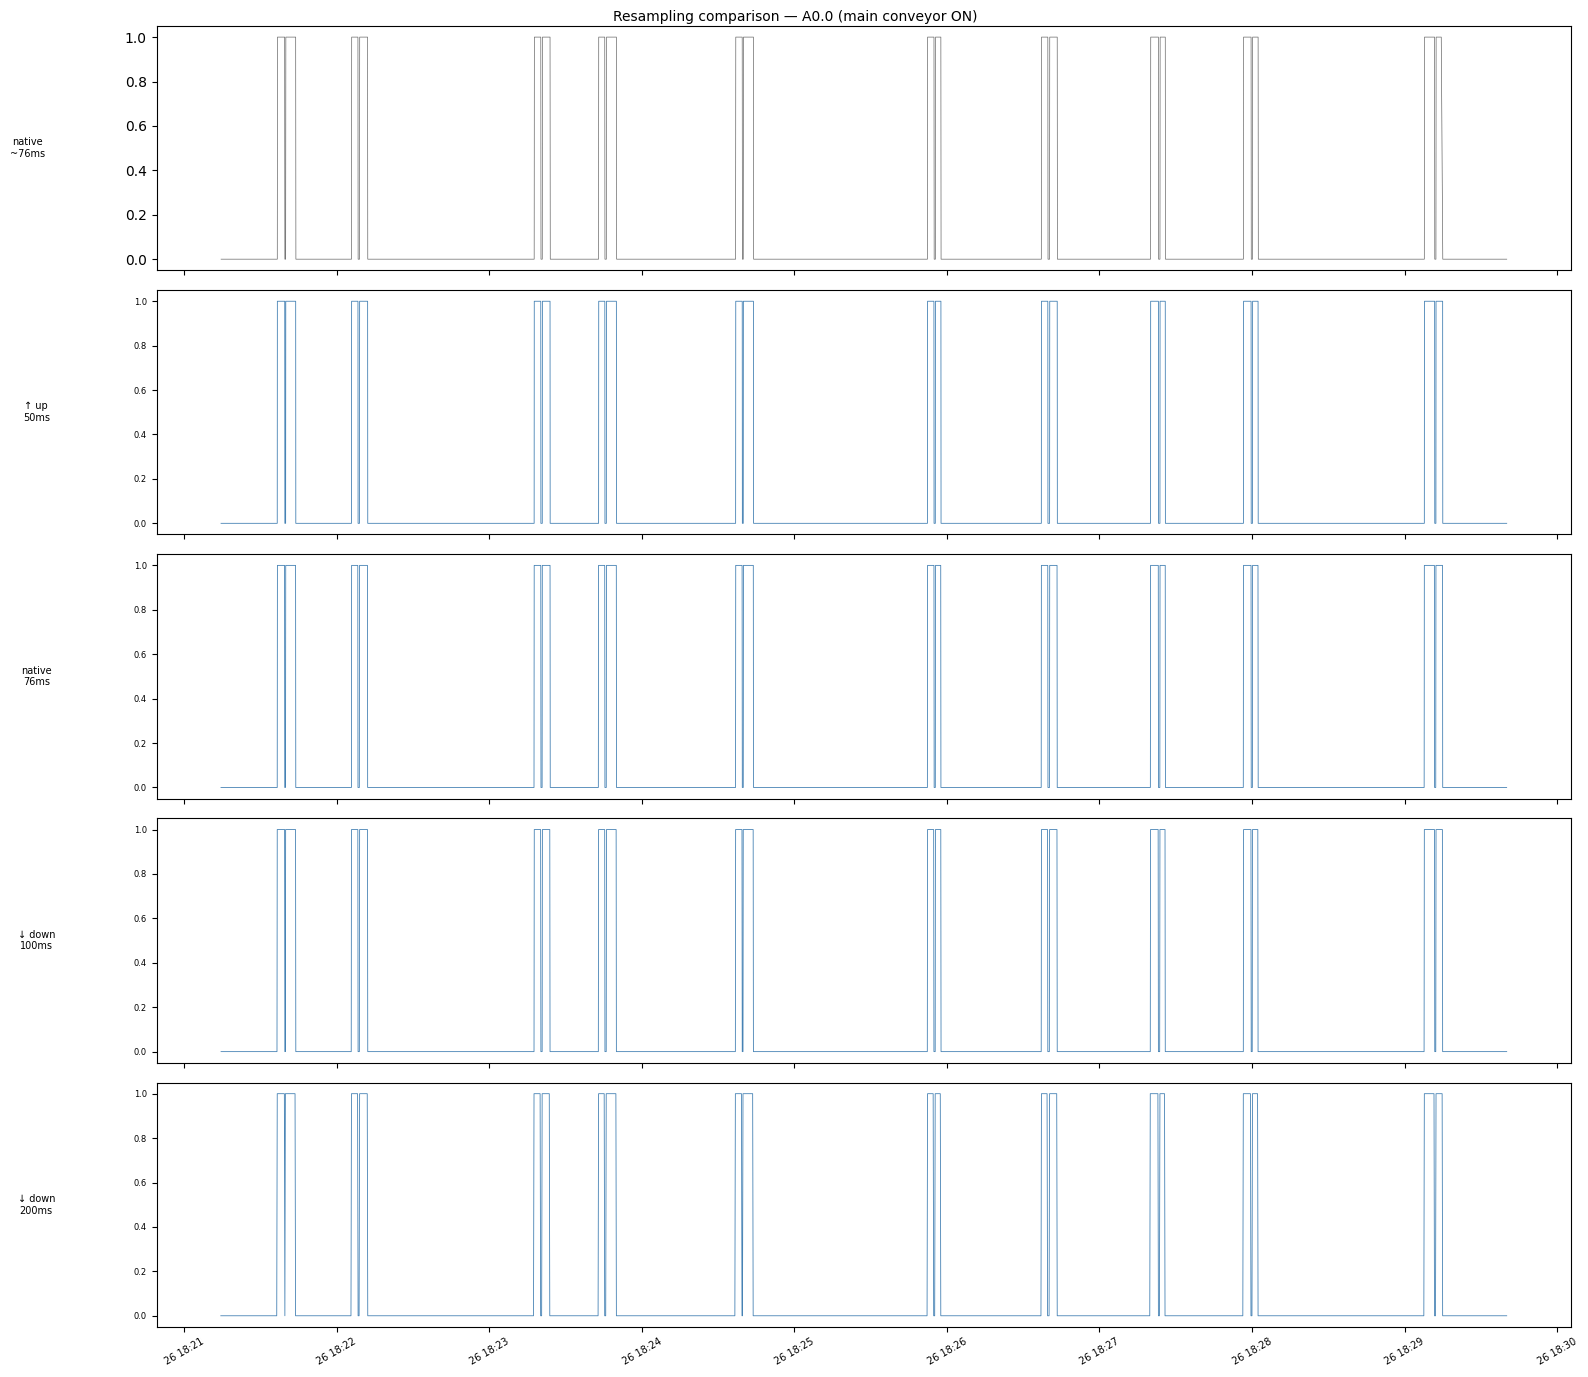

Saved: resampling_comparison.png


In [12]:
# -----------------------------------------------------------------------------
# 3.5  VISUAL COMPARISON — same signal at all four grids
# — Shows concretely what each grid costs in temporal resolution
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(len(GRIDS) + 1, 1, figsize=(16, 14), sharex=True)
fig.suptitle("Resampling comparison — A0.0 (main conveyor ON)", fontsize=10)

# Native rate reference
axes[0].plot(df_s["timestamp"], df_s["A0.0"].astype(float),
             lw=0.5, color="dimgray")
axes[0].set_ylabel("native\n~76ms", fontsize=7, rotation=0,
                   labelpad=70, va="center")

for ax, g in zip(axes[1:], GRIDS):
    label = ("↑ up" if g < 76 else ("native" if g == 76 else "↓ down"))
    ax.plot(resampled_s[g]["timestamp"], resampled_s[g]["A0.0"].astype(float),
            lw=0.6, color="steelblue")
    ax.set_ylabel(f"{label}\n{g}ms", fontsize=7, rotation=0,
                  labelpad=70, va="center")
    ax.tick_params(axis="y", labelsize=6)

axes[-1].tick_params(axis="x", labelsize=7, rotation=30)
plt.tight_layout()
plt.savefig("resampling_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: resampling_comparison.png")

In [13]:
# =============================================================================
# 4.  PER-CYCLE FEATURE ENGINEERING
# — One row per cycle summarising what happened across both PLCs
# — These become the input vectors for anomaly detection / clustering
# =============================================================================

pd.set_option('future.no_silent_downcasting', True)   # silence pandas warning

# Work on the 100ms merged dataframe — carry cycle_id across from Siemens
# -----------------------------------------------------------------------------
# 4.0  RE-ATTACH CYCLE LABELS TO MERGED 100ms DATAFRAME
# -----------------------------------------------------------------------------

# Resample cycle_id the same way (forward-fill — a row belongs to the cycle
# it was logged in, not interpolated between cycles)
cycle_id_resampled = (
    df_s[["timestamp", "cycle_id"]]
    .set_index("timestamp")
    .resample("100ms")
    .last()
    .ffill()
    .reset_index()
)

df_work = merged[100].merge(cycle_id_resampled, on="timestamp", how="left")
df_work = df_work.dropna(subset=["cycle_id"])   # drop idle rows between cycles
df_work["cycle_id"] = df_work["cycle_id"].astype(int)

print(f"Working dataframe : {df_work.shape}")
print(f"Cycles present    : {sorted(df_work['cycle_id'].unique())}")




Working dataframe : (5058, 197)
Cycles present    : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


In [14]:
# -----------------------------------------------------------------------------
# 4.1  DEFINE FEATURE GROUPS
# — Keep names tidy: _s suffix = Siemens origin, _b = Beckhoff origin
# -----------------------------------------------------------------------------

# Siemens binary outputs — machine actuations
SIG_ACTUATORS = ["A0.0", "A1.0", "A0.1", "A0.2", "A0.3",
                 "A0.4", "A0.5", "A0.6", "A0.7"]

# Siemens binary inputs — sensors / light barriers
SIG_SENSORS_S = ["E0.1", "E0.2", "E1.0"]

# Siemens numeric registers
SIG_NUMERIC_S = ["MW22", "MW12", "MW14", "MW16", "MW18", "MW20"]

# Beckhoff warehouse signals
SIG_WH = [c for c in df_work.columns if c.startswith("WH")]

# Beckhoff encoder (high-freq toggling signal)
SIG_ENC = [c for c in df_work.columns
           if "encoder" in c.lower() or c.endswith("_b") and "B1" in c]


# -----------------------------------------------------------------------------
# 4.2  FEATURE EXTRACTION FUNCTION
# — For each cycle slice, compute summary statistics per signal group
# -----------------------------------------------------------------------------

def extract_cycle_features(grp):
    feats = {}

    # --- cycle timing ---
    feats["duration_s"]      = (grp["timestamp"].max()
                                - grp["timestamp"].min()).total_seconds()
    feats["n_samples"]       = len(grp)

    # --- actuator ON-time fractions (duty cycle per output) ---
    for col in SIG_ACTUATORS:
        if col in grp.columns:
            feats[f"duty_{col}"] = grp[col].fillna(0).mean()

    # --- sensor pulse counts (rising edges within cycle) ---
    for col in SIG_SENSORS_S:
        if col in grp.columns:
            s = grp[col].fillna(0).astype(int)
            feats[f"pulses_{col}"] = int(((s.shift(1) == 0) & (s == 1)).sum())

    # --- numeric registers: mean + std ---
    for col in SIG_NUMERIC_S:
        if col in grp.columns:
            feats[f"mean_{col}"] = grp[col].mean()
            feats[f"std_{col}"]  = grp[col].std()

    # --- MW22 state dwell times (how long in each PLC state) ---
    for state in [1, 2, 3]:
        col = "MW22"
        if col in grp.columns:
            feats[f"dwell_MW22_{state}"] = (
                (grp[col].round() == state).sum() * 0.1   # × 100ms → seconds
            )

    # --- Beckhoff warehouse: pulse counts + duty ---
    for col in SIG_WH:
        if col in grp.columns:
            s = grp[col].fillna(0)
            if s.isin([0, 1]).all():
                feats[f"duty_{col}"]   = s.mean()
                feats[f"pulses_{col}"] = int(
                    ((s.astype(int).shift(1) == 0) & (s.astype(int) == 1)).sum()
                )
            else:
                feats[f"mean_{col}"]  = s.mean()
                feats[f"std_{col}"]   = s.std()

    # --- Encoder activity: transition count as proxy for travel distance ---
    for col in SIG_ENC:
        if col in grp.columns:
            s = grp[col].fillna(0).astype(float)
            diff = s.diff().abs()
            feats[f"enc_transitions_{col}"] = int((diff > 0.5).sum())
            feats[f"enc_mean_{col}"]        = s.mean()

    return pd.Series(feats)




In [15]:
# -----------------------------------------------------------------------------
# 4.3  APPLY ACROSS ALL CYCLES
# -----------------------------------------------------------------------------

cycle_features = (
    df_work.groupby("cycle_id")
    .apply(extract_cycle_features)
    .reset_index()
)

print(f"\nFeature matrix shape : {cycle_features.shape}")
print(f"Features extracted   : {cycle_features.shape[1] - 1}")
print(cycle_features.drop(columns="cycle_id").describe().round(3).T
      .to_string())





Feature matrix shape : (10, 108)
Features extracted   : 107
                                                   count      mean      std       min       25%       50%       75%       max
duration_s                                          10.0    50.480   17.829    23.900    38.100    53.750    65.300    71.900
n_samples                                           10.0   505.800  178.294   240.000   382.000   538.500   654.000   720.000
duty_A0.0                                           10.0     0.133    0.056     0.081     0.090     0.109     0.175     0.224
duty_A1.0                                           10.0     0.027    0.023     0.000     0.015     0.019     0.037     0.082
duty_A0.1                                           10.0     0.015    0.013     0.006     0.008     0.009     0.018     0.049
duty_A0.2                                           10.0     0.005    0.007     0.000     0.000     0.000     0.009     0.021
duty_A0.3                                           10.0 

/var/folders/_0/m4p809gj0td9pvyzj5x5yyp80000gn/T/ipykernel_13702/3780239922.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_work.groupby("cycle_id")


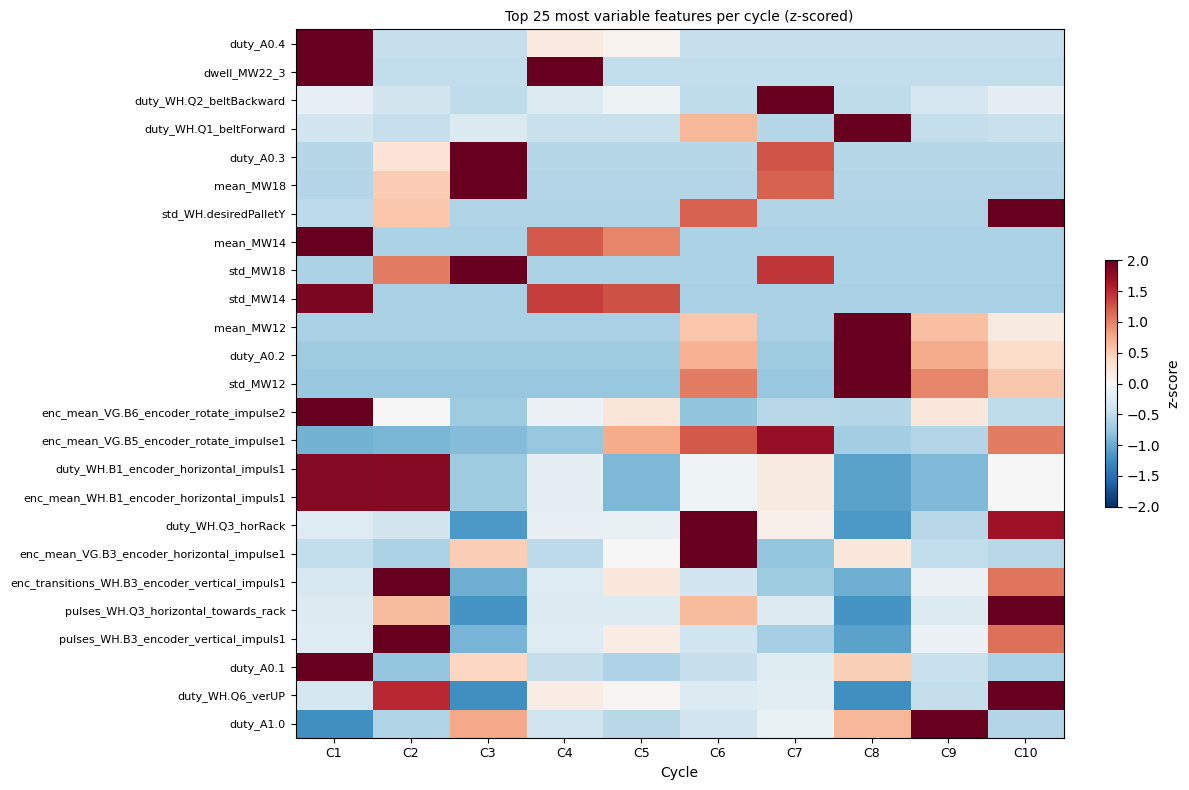

Saved: cycle_heatmap_top25.png


In [16]:
# =============================================================================
# 4.4  HEATMAP — top features by variance only (readable version)
# =============================================================================

from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- drop duplicate/alias Beckhoff columns before feature selection ---
# keep the longer descriptive name where duplicates exist
alias_drops = [
    "WH.Q3_horRack", "WH.Q4_horBelt",
    "WH.Q5_verDown", "WH.Q6_verUP",
    "WH.Q7_cantForw", "WH.Q8_cantBack",
]
cycle_features_clean = cycle_features.drop(
    columns=[c for c in alias_drops if c in cycle_features.columns]
)

# --- drop all-zero / all-constant features ---
feat_cols = [c for c in cycle_features_clean.columns if c != "cycle_id"]
X_df = cycle_features_clean[feat_cols].fillna(0)
X_df = X_df.loc[:, X_df.std() > 0]          # remove zero-variance cols
feat_cols = X_df.columns.tolist()

# --- rank by coefficient of variation (std/mean) — most variable features ---
cv = (X_df.std() / X_df.mean().replace(0, np.nan)).abs().fillna(0)
top_feats = cv.nlargest(25).index.tolist()   # top 25 most variable

X_top    = X_df[top_feats].values
X_scaled = StandardScaler().fit_transform(X_top)

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(X_scaled.T, aspect="auto", cmap="RdBu_r", vmin=-2, vmax=2)

ax.set_yticks(range(len(top_feats)))
ax.set_yticklabels(top_feats, fontsize=8)
ax.set_xticks(range(len(cycle_features_clean)))
ax.set_xticklabels(
    [f"C{int(i)}" for i in cycle_features_clean["cycle_id"]], fontsize=9
)
ax.set_xlabel("Cycle")
ax.set_title("Top 25 most variable features per cycle (z-scored)", fontsize=10)
plt.colorbar(im, ax=ax, fraction=0.015, label="z-score")
plt.tight_layout()
plt.savefig("cycle_heatmap_top25.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cycle_heatmap_top25.png")



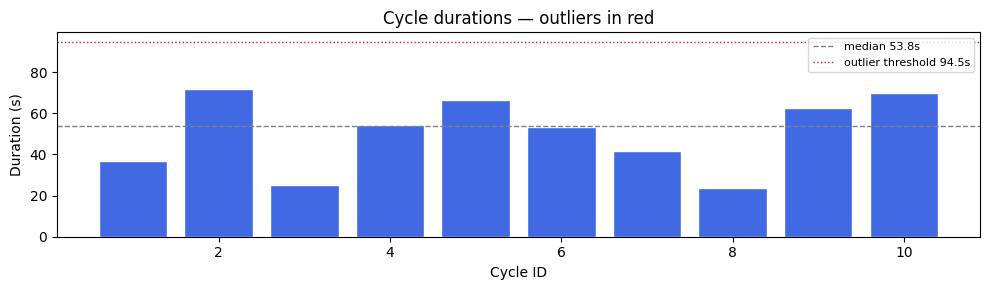

Saved: cycle_durations.png


In [17]:
# -----------------------------------------------------------------------------
# 4.5  CYCLE DURATION OVERVIEW — flag outlier cycles visually
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 3))
bars = ax.bar(cycle_features["cycle_id"].astype(int),
              cycle_features["duration_s"],
              color="royalblue", edgecolor="white")

# Highlight cycles > 1.5 IQR from median
med = cycle_features["duration_s"].median()
iqr = cycle_features["duration_s"].quantile(0.75) - \
      cycle_features["duration_s"].quantile(0.25)
threshold = med + 1.5 * iqr

for bar, dur in zip(bars, cycle_features["duration_s"]):
    if dur > threshold:
        bar.set_color("crimson")
        ax.text(bar.get_x() + bar.get_width()/2, dur + 0.5,
                f"{dur:.1f}s", ha="center", fontsize=7, color="crimson")

ax.axhline(med, color="gray", lw=1, linestyle="--", label=f"median {med:.1f}s")
ax.axhline(med + 1.5*iqr, color="crimson", lw=1,
           linestyle=":", label=f"outlier threshold {threshold:.1f}s")
ax.set_xlabel("Cycle ID")
ax.set_ylabel("Duration (s)")
ax.set_title("Cycle durations — outliers in red")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("cycle_durations.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cycle_durations.png")

In [18]:
# =============================================================================
# 4.6  SHORT vs LONG CYCLE ANALYSIS
# — The alternating duration pattern suggests two cycle types
# — Split and compare feature means between them
# =============================================================================

med_dur = cycle_features_clean["duration_s"].median()
cycle_features_clean["cycle_type"] = np.where(
    cycle_features_clean["duration_s"] < med_dur, "short", "long"
)

print("\nCycle type assignment:")
print(cycle_features_clean[["cycle_id", "duration_s", "cycle_type"]]
      .to_string(index=False))

# Mean of top features by cycle type
comparison = (
    cycle_features_clean.groupby("cycle_type")[top_feats]
    .mean()
    .T
    .round(3)
)
comparison["ratio_long_short"] = (
    comparison["long"] / comparison["short"].replace(0, np.nan)
).round(2)
comparison = comparison.sort_values("ratio_long_short", ascending=False)

print("\nFeature means by cycle type (sorted by long/short ratio):")
print(comparison.to_string())


Cycle type assignment:
 cycle_id  duration_s cycle_type
        1        37.0      short
        2        71.9       long
        3        24.9      short
        4        54.1       long
        5        66.3       long
        6        53.4      short
        7        41.4      short
        8        23.9      short
        9        62.3       long
       10        69.6       long

Feature means by cycle type (sorted by long/short ratio):
cycle_type                                         long   short  ratio_long_short
enc_transitions_WH.B3_encoder_vertical_impuls1   28.000   7.600              3.68
pulses_WH.B3_encoder_vertical_impuls1            13.800   4.000              3.45
duty_WH.Q6_verUP                                  0.040   0.012              3.33
pulses_WH.Q3_horizontal_towards_rack              1.800   0.800              2.25
std_WH.desiredPalletY                           109.408  48.568              2.25
std_MW14                                          0.573   0.36

In [19]:
# =============================================================================
# 5.  ANOMALY SCORING PER CYCLE
# — With only 10 cycles, classical ML won't generalise
# — Use Isolation Forest + z-score distance as complementary scores
# — Goal: rank cycles by "how unusual" they are, with feature attribution
# =============================================================================

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# 5.1  PREPARE FEATURE MATRIX
# — Use the clean top-25 variable features from step 4
# — Already computed: X_df[top_feats], cycle_features_clean
# -----------------------------------------------------------------------------

X_anom   = X_df[top_feats].fillna(0)
X_scaled = StandardScaler().fit_transform(X_anom)
cycle_ids = cycle_features_clean["cycle_id"].values

# -----------------------------------------------------------------------------
# 5.2  Z-SCORE DISTANCE — how far each cycle is from the feature mean
# — Simple, fully interpretable: one number per cycle
# — Mahalanobis-lite: sum of squared z-scores across all features
# -----------------------------------------------------------------------------

z_scores     = np.abs(X_scaled)                     # |z| per feature per cycle
anomaly_zscore = np.sqrt((z_scores ** 2).sum(axis=1))  # L2 distance from mean



In [20]:
# -----------------------------------------------------------------------------
# 5.3  ISOLATION FOREST
# — contamination='auto' since we have no labelled anomalies
# — score_samples gives raw anomaly score (more negative = more anomalous)
# — With n=10 treat this as a ranking tool, not a hard classifier
# -----------------------------------------------------------------------------

iso = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42
)
iso.fit(X_scaled)
iso_scores = -iso.score_samples(X_scaled)   # flip sign: higher = more anomalous

# -----------------------------------------------------------------------------
# 5.4  COMBINED RANKING TABLE
# -----------------------------------------------------------------------------

anomaly_df = pd.DataFrame({
    "cycle_id"      : cycle_ids,
    "duration_s"    : cycle_features_clean["duration_s"].values,
    "cycle_type"    : cycle_features_clean["cycle_type"].values,
    "zscore_dist"   : anomaly_zscore.round(3),
    "iso_score"     : iso_scores.round(4),
}).sort_values("zscore_dist", ascending=False).reset_index(drop=True)

anomaly_df["rank_zscore"] = range(1, len(anomaly_df) + 1)
anomaly_df = anomaly_df.sort_values("iso_score", ascending=False)
anomaly_df["rank_iso"]    = range(1, len(anomaly_df) + 1)
anomaly_df = anomaly_df.sort_values("zscore_dist", ascending=False)

print("Anomaly ranking (most anomalous first by z-score distance):")
print(anomaly_df.to_string(index=False))



Anomaly ranking (most anomalous first by z-score distance):
 cycle_id  duration_s cycle_type  zscore_dist  iso_score  rank_zscore  rank_iso
        1        37.0      short        7.007     0.5393            1         1
        8        23.9      short        6.149     0.5026            2         4
        3        24.9      short        5.376     0.5076            3         3
        2        71.9       long        5.337     0.5131            4         2
       10        69.6       long        5.170     0.4863            5         5
        7        41.4      short        4.737     0.4790            6         6
        6        53.4      short        4.601     0.4675            7         7
        9        62.3       long        3.751     0.4218            8         9
        4        54.1       long        3.498     0.4137            9        10
        5        66.3       long        3.011     0.4246           10         8


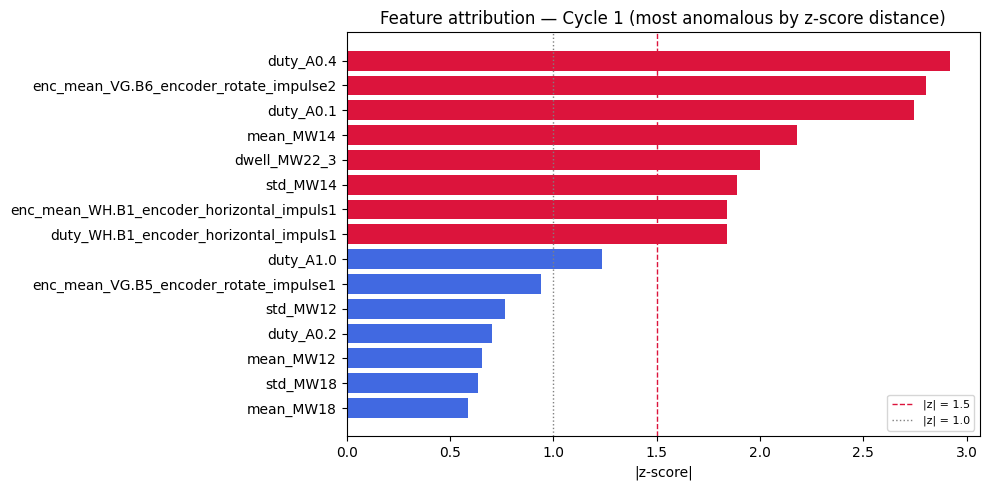

In [21]:
# -----------------------------------------------------------------------------
# 5.5  FEATURE ATTRIBUTION FOR TOP ANOMALOUS CYCLE
# — Which features pushed the most anomalous cycle furthest from normal?
# — Bar chart of |z-score| per feature for that cycle
# -----------------------------------------------------------------------------

top_anomaly_idx = anomaly_df.iloc[0]["cycle_id"]
top_idx_pos     = list(cycle_ids).index(top_anomaly_idx)
z_top           = z_scores[top_idx_pos]

attr_df = pd.DataFrame({
    "feature" : top_feats,
    "abs_z"   : z_top
}).sort_values("abs_z", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["crimson" if z > 1.5 else "royalblue" for z in attr_df["abs_z"]]
ax.barh(attr_df["feature"], attr_df["abs_z"], color=colors)
ax.axvline(1.5, color="crimson", lw=1, linestyle="--", label="|z| = 1.5")
ax.axvline(1.0, color="gray",   lw=1, linestyle=":",  label="|z| = 1.0")
ax.set_xlabel("|z-score|")
ax.set_title(f"Feature attribution — Cycle {int(top_anomaly_idx)} "
             f"(most anomalous by z-score distance)")
ax.legend(fontsize=8)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("anomaly_attribution.png", dpi=150, bbox_inches="tight")
plt.show()



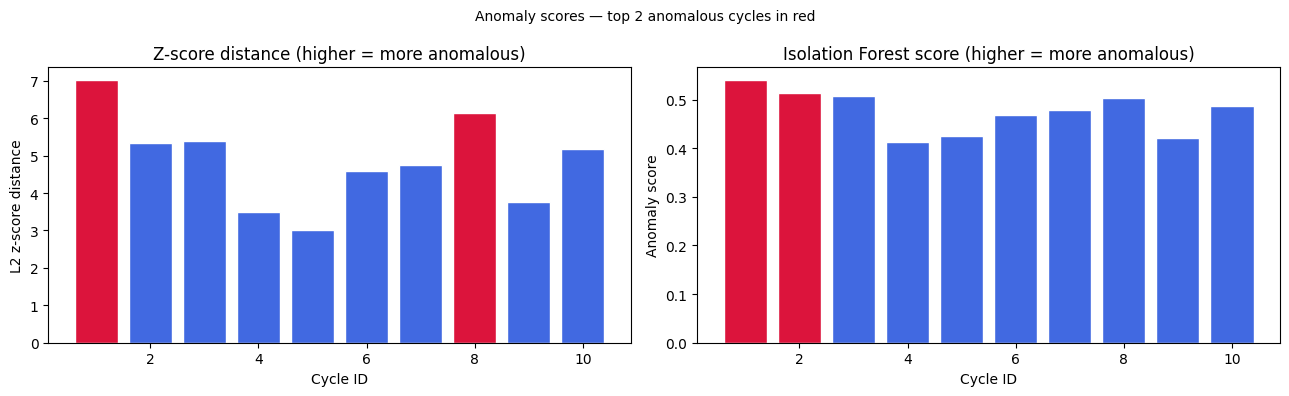

Saved: anomaly_scores.png, anomaly_attribution.png


In [22]:
# -----------------------------------------------------------------------------
# 5.6  ANOMALY SCORE OVERVIEW — both methods side by side
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# z-score distance
ax = axes[0]
colors = ["crimson" if r <= 2 else "royalblue"
          for r in anomaly_df.sort_values("cycle_id")["rank_zscore"]]
ax.bar(anomaly_df.sort_values("cycle_id")["cycle_id"].astype(int),
       anomaly_df.sort_values("cycle_id")["zscore_dist"],
       color=colors, edgecolor="white")
ax.set_title("Z-score distance (higher = more anomalous)")
ax.set_xlabel("Cycle ID")
ax.set_ylabel("L2 z-score distance")

# Isolation Forest score
ax = axes[1]
colors = ["crimson" if r <= 2 else "royalblue"
          for r in anomaly_df.sort_values("cycle_id")["rank_iso"]]
ax.bar(anomaly_df.sort_values("cycle_id")["cycle_id"].astype(int),
       anomaly_df.sort_values("cycle_id")["iso_score"],
       color=colors, edgecolor="white")
ax.set_title("Isolation Forest score (higher = more anomalous)")
ax.set_xlabel("Cycle ID")
ax.set_ylabel("Anomaly score")

plt.suptitle("Anomaly scores — top 2 anomalous cycles in red", fontsize=10)
plt.tight_layout()
plt.savefig("anomaly_scores.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: anomaly_scores.png, anomaly_attribution.png")

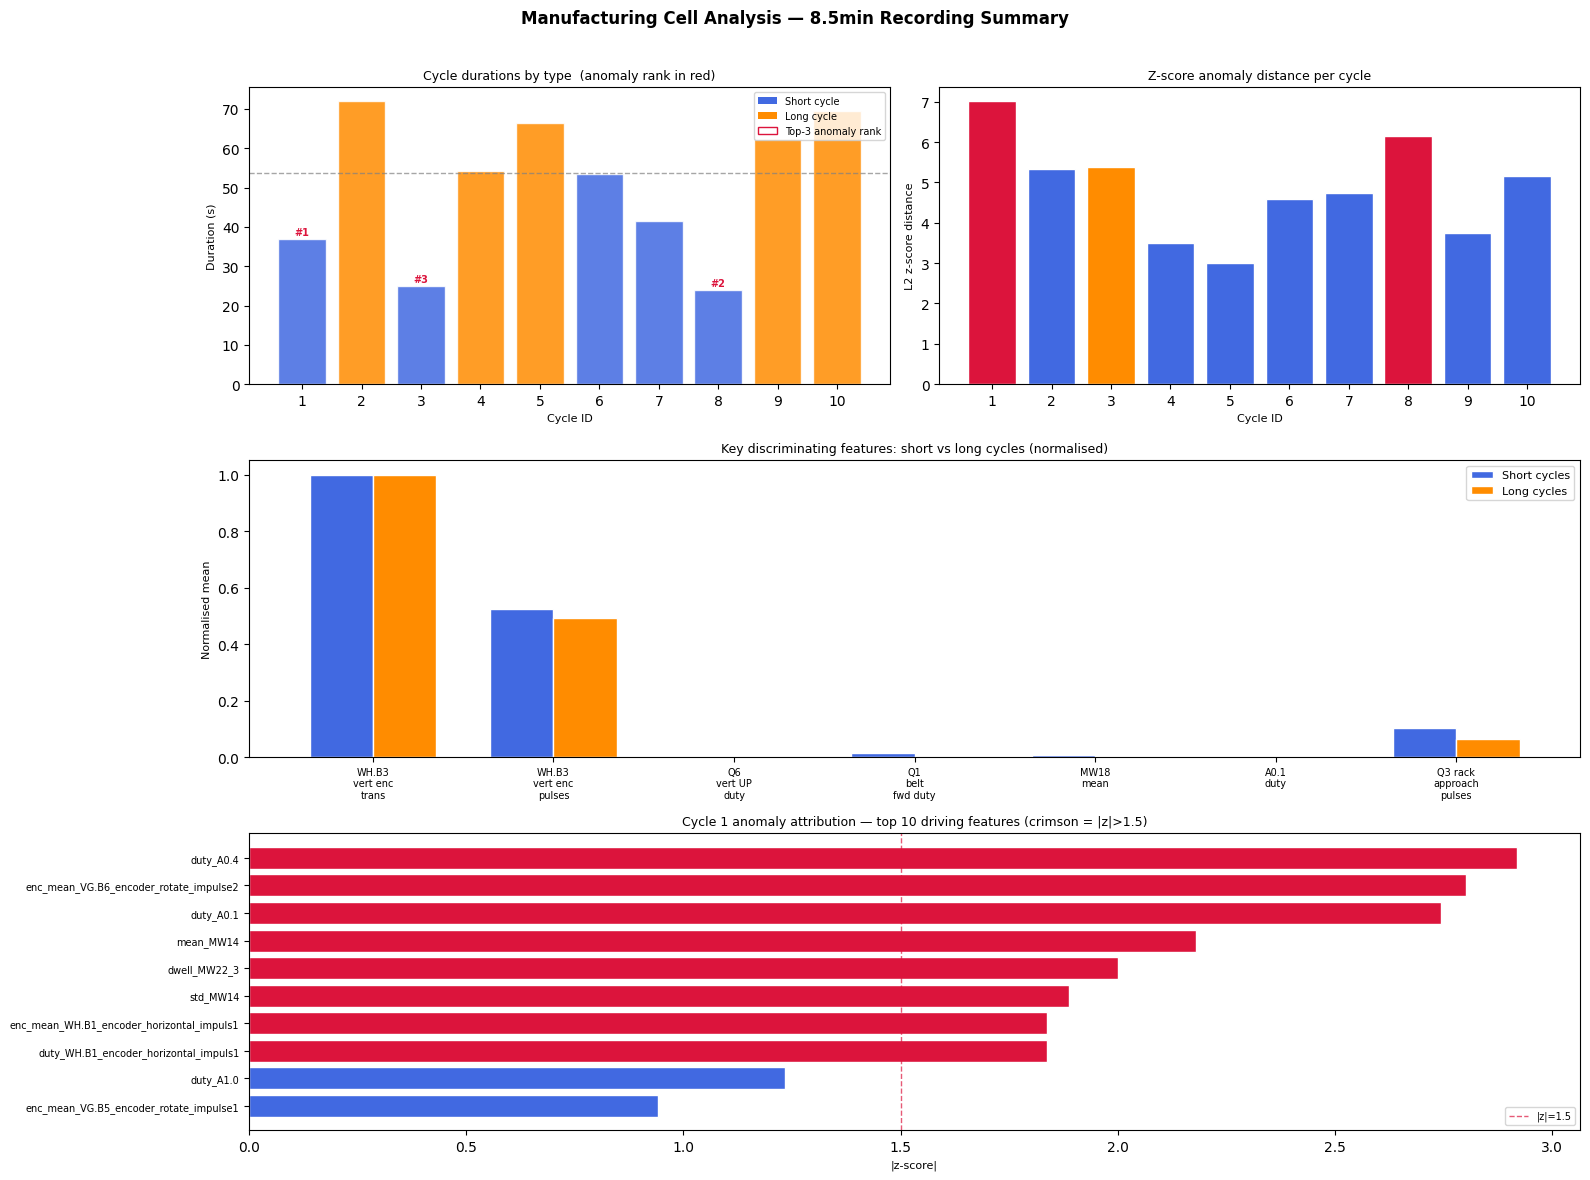

Saved: final_summary.png


In [23]:
# =============================================================================
# 6.  FINAL SUMMARY — combined findings visualisation
# =============================================================================

fig = plt.figure(figsize=(16, 12))
fig.suptitle("Manufacturing Cell Analysis — 8.5min Recording Summary",
             fontsize=12, fontweight="bold", y=0.98)

# --- layout: 3 rows, 2 cols ---
ax1 = fig.add_subplot(3, 2, 1)
ax2 = fig.add_subplot(3, 2, 2)
ax3 = fig.add_subplot(3, 1, 2)
ax4 = fig.add_subplot(3, 1, 3)

# ------------------------------------------------------------------
# Panel 1 — cycle durations coloured by type + anomaly rank
# ------------------------------------------------------------------
type_colors = {"short": "royalblue", "long": "darkorange"}
ctype = cycle_features_clean.set_index("cycle_id")["cycle_type"]

for _, row in cycle_features_clean.iterrows():
    cid = int(row["cycle_id"])
    col = type_colors[row["cycle_type"]]
    ax1.bar(cid, row["duration_s"], color=col,
            edgecolor="white", alpha=0.85)

for _, row in anomaly_df.iterrows():
    cid = int(row["cycle_id"])
    dur = cycle_features_clean.loc[
        cycle_features_clean["cycle_id"] == row["cycle_id"],
        "duration_s"].values[0]
    if row["rank_zscore"] <= 3:
        ax1.text(cid, dur + 1, f"#{int(row['rank_zscore'])}",
                 ha="center", fontsize=7, color="crimson", fontweight="bold")

ax1.axhline(cycle_features_clean["duration_s"].median(),
            color="gray", lw=1, linestyle="--", alpha=0.7)
from matplotlib.patches import Patch
legend_els = [Patch(facecolor="royalblue",  label="Short cycle"),
              Patch(facecolor="darkorange", label="Long cycle"),
              Patch(facecolor="white", edgecolor="crimson",
                    label="Top-3 anomaly rank")]
ax1.legend(handles=legend_els, fontsize=7, loc="upper right")
ax1.set_title("Cycle durations by type  (anomaly rank in red)", fontsize=9)
ax1.set_xlabel("Cycle ID", fontsize=8)
ax1.set_ylabel("Duration (s)", fontsize=8)
ax1.set_xticks(cycle_features_clean["cycle_id"].astype(int))

# ------------------------------------------------------------------
# Panel 2 — z-score anomaly scores
# ------------------------------------------------------------------
adf_sorted = anomaly_df.sort_values("cycle_id")
colors_anom = ["crimson" if r <= 2 else
               "darkorange" if r == 3 else "royalblue"
               for r in adf_sorted["rank_zscore"]]
ax2.bar(adf_sorted["cycle_id"].astype(int),
        adf_sorted["zscore_dist"],
        color=colors_anom, edgecolor="white")
ax2.set_title("Z-score anomaly distance per cycle", fontsize=9)
ax2.set_xlabel("Cycle ID", fontsize=8)
ax2.set_ylabel("L2 z-score distance", fontsize=8)
ax2.set_xticks(adf_sorted["cycle_id"].astype(int))

# ------------------------------------------------------------------
# Panel 3 — short vs long: top discriminating features
# ------------------------------------------------------------------
top_disc = ["enc_transitions_WH.B3_encoder_vertical_impuls1",
            "pulses_WH.B3_encoder_vertical_impuls1",
            "duty_WH.Q6_verUP",
            "duty_WH.Q1_beltForward",
            "mean_MW18",
            "duty_A0.1",
            "pulses_WH.Q3_horizontal_towards_rack"]

short_means = cycle_features_clean[
    cycle_features_clean["cycle_type"] == "short"][top_disc].mean()
long_means  = cycle_features_clean[
    cycle_features_clean["cycle_type"] == "long"][top_disc].mean()

norm = lambda s: (s - s.min()) / (s.max() - s.min() + 1e-9)
short_n = norm(short_means)
long_n  = norm(long_means)

x = np.arange(len(top_disc))
w = 0.35
ax3.bar(x - w/2, short_n, w, label="Short cycles", color="royalblue",
        edgecolor="white")
ax3.bar(x + w/2, long_n,  w, label="Long cycles",  color="darkorange",
        edgecolor="white")
ax3.set_xticks(x)
short_labels = ["WH.B3\nvert enc\ntrans",
                "WH.B3\nvert enc\npulses",
                "Q6\nvert UP\nduty",
                "Q1\nbelt\nfwd duty",
                "MW18\nmean",
                "A0.1\nduty",
                "Q3 rack\napproach\npulses"]
ax3.set_xticklabels(short_labels, fontsize=7)
ax3.set_title("Key discriminating features: short vs long cycles (normalised)",
              fontsize=9)
ax3.set_ylabel("Normalised mean", fontsize=8)
ax3.legend(fontsize=8)

# ------------------------------------------------------------------
# Panel 4 — C1 attribution (top 10 only for readability)
# ------------------------------------------------------------------
attr_top10 = attr_df.head(10)
colors_attr = ["crimson" if z > 1.5 else "royalblue"
               for z in attr_top10["abs_z"]]
ax4.barh(attr_top10["feature"], attr_top10["abs_z"],
         color=colors_attr, edgecolor="white")
ax4.axvline(1.5, color="crimson", lw=1, linestyle="--",
            alpha=0.7, label="|z|=1.5")
ax4.set_xlabel("|z-score|", fontsize=8)
ax4.set_title("Cycle 1 anomaly attribution — top 10 driving features "
              "(crimson = |z|>1.5)", fontsize=9)
ax4.invert_yaxis()
ax4.tick_params(axis="y", labelsize=7)
ax4.legend(fontsize=7)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("final_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: final_summary.png")

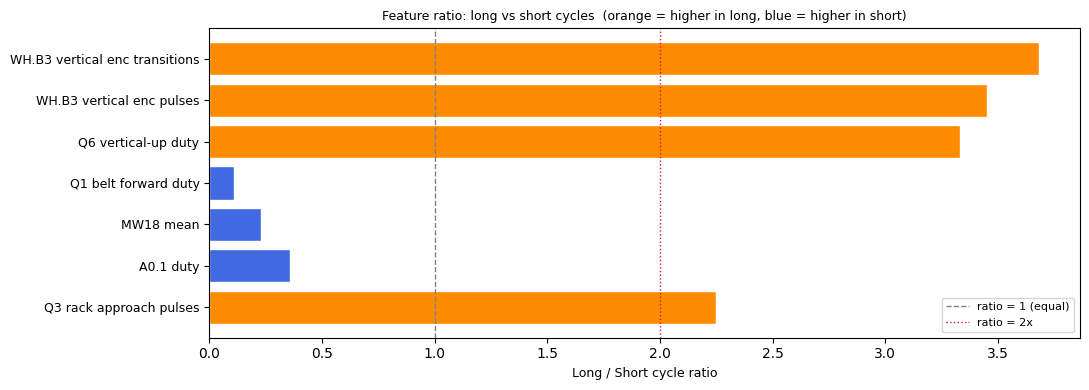

In [24]:
top_disc = [
    "enc_transitions_WH.B3_encoder_vertical_impuls1",
    "pulses_WH.B3_encoder_vertical_impuls1",
    "duty_WH.Q6_verUP",
    "duty_WH.Q1_beltForward",
    "mean_MW18",
    "duty_A0.1",
    "pulses_WH.Q3_horizontal_towards_rack",
]
ratio_data = comparison.loc[top_disc, "ratio_long_short"].dropna()

fig, ax = plt.subplots(figsize=(11, 4))
colors = ["darkorange" if r > 1 else "royalblue" for r in ratio_data]
ax.barh(ratio_data.index, ratio_data.values, color=colors, edgecolor="white")
ax.axvline(1.0, color="gray", lw=1, linestyle="--", label="ratio = 1 (equal)")
ax.axvline(2.0, color="crimson", lw=1, linestyle=":", label="ratio = 2x")

clean_labels = [
    "WH.B3 vertical enc transitions",
    "WH.B3 vertical enc pulses",
    "Q6 vertical-up duty",
    "Q1 belt forward duty",
    "MW18 mean",
    "A0.1 duty",
    "Q3 rack approach pulses",
]
ax.set_yticks(range(len(ratio_data)))
ax.set_yticklabels(clean_labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Long / Short cycle ratio", fontsize=9)
ax.set_title("Feature ratio: long vs short cycles  "
             "(orange = higher in long, blue = higher in short)", fontsize=9)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("feature_ratio_long_short.png", dpi=150, bbox_inches="tight")
plt.show()

In [25]:
# =============================================================================
# 7.  ANOMALY FREQUENCY ANALYSIS
# — How frequently do performance loss events occur?
# — Are they clustered, random, or periodic?
# =============================================================================

# -----------------------------------------------------------------------------
# 7.1  CYCLE TIMELINE — when did each cycle occur and was it anomalous?
# -----------------------------------------------------------------------------

# Build timeline from cycle_summary (already computed in cell 8)
cycle_timeline = cycle_summary.copy().reset_index()
cycle_timeline.columns = ["cycle_id", "start", "end", "n_rows", "duration_s"]

# Attach anomaly rank and cycle type
cycle_timeline = cycle_timeline.merge(
    anomaly_df[["cycle_id", "rank_zscore", "rank_iso", "zscore_dist"]],
    on="cycle_id"
)
cycle_timeline = cycle_timeline.merge(
    cycle_features_clean[["cycle_id", "cycle_type"]],
    on="cycle_id"
)

# Flag anomalous cycles
cycle_timeline["status"] = "Normal"
cycle_timeline.loc[cycle_timeline["rank_zscore"] == 1, "status"] = "Confirmed"
cycle_timeline.loc[cycle_timeline["rank_zscore"] == 2, "status"] = "Candidate"
cycle_timeline.loc[cycle_timeline["rank_zscore"] == 3, "status"] = "Borderline"

# Inter-cycle gap (idle time between cycles)
cycle_timeline["gap_to_next_s"] = (
    cycle_timeline["start"].shift(-1) - cycle_timeline["end"]
).dt.total_seconds()

# Time from recording start
t0 = cycle_timeline["start"].min()
cycle_timeline["elapsed_s"] = (
    cycle_timeline["start"] - t0
).dt.total_seconds()

print("Cycle timeline with anomaly status:")
print(cycle_timeline[[
    "cycle_id", "elapsed_s", "duration_s",
    "gap_to_next_s", "cycle_type", "status"
]].to_string(index=False))



Cycle timeline with anomaly status:
 cycle_id  elapsed_s  duration_s  gap_to_next_s cycle_type     status
      1.0      0.000      35.812          1.326      short  Confirmed
      2.0     37.138      70.633          1.355       long     Normal
      3.0    109.126      23.805          1.235      short Borderline
      4.0    134.166      52.828          1.338       long     Normal
      5.0    188.332      65.199          1.241       long     Normal
      6.0    254.772      52.337          1.150      short     Normal
      7.0    308.259      40.250          1.201      short     Normal
      8.0    349.710      22.779          1.212      short  Candidate
      9.0    373.701      61.147          1.299       long     Normal
     10.0    436.147      69.551            NaN       long     Normal


In [26]:
# -----------------------------------------------------------------------------
# 7.2  FREQUENCY METRICS
# -----------------------------------------------------------------------------

total_cycles     = len(cycle_timeline)
anomalous        = cycle_timeline[cycle_timeline["status"] != "Normal"]
confirmed        = cycle_timeline[cycle_timeline["status"] == "Confirmed"]
recording_mins   = (cycle_timeline["end"].max() -
                    cycle_timeline["start"].min()).total_seconds() / 60

avg_cycle_time   = cycle_timeline["duration_s"].mean()
cycle_rate       = total_cycles / recording_mins  # cycles per minute
anomaly_rate_pct = len(anomalous) / total_cycles * 100

print(f"\n--- Frequency Summary ---")
print(f"Recording duration      : {recording_mins:.1f} minutes")
print(f"Total cycles            : {total_cycles}")
print(f"Cycle rate              : {cycle_rate:.2f} cycles/minute")
print(f"Avg cycle time          : {avg_cycle_time:.1f}s")
print(f"Confirmed anomalies     : {len(confirmed)}")
print(f"Candidate + borderline  : {len(anomalous) - len(confirmed)}")
print(f"Anomaly rate            : {anomaly_rate_pct:.1f}% of cycles")
print(f"Anomaly frequency       : ~1 every "
      f"{recording_mins / max(len(anomalous),1):.1f} minutes")




--- Frequency Summary ---
Recording duration      : 8.4 minutes
Total cycles            : 10
Cycle rate              : 1.19 cycles/minute
Avg cycle time          : 49.4s
Confirmed anomalies     : 1
Candidate + borderline  : 2
Anomaly rate            : 30.0% of cycles
Anomaly frequency       : ~1 every 2.8 minutes


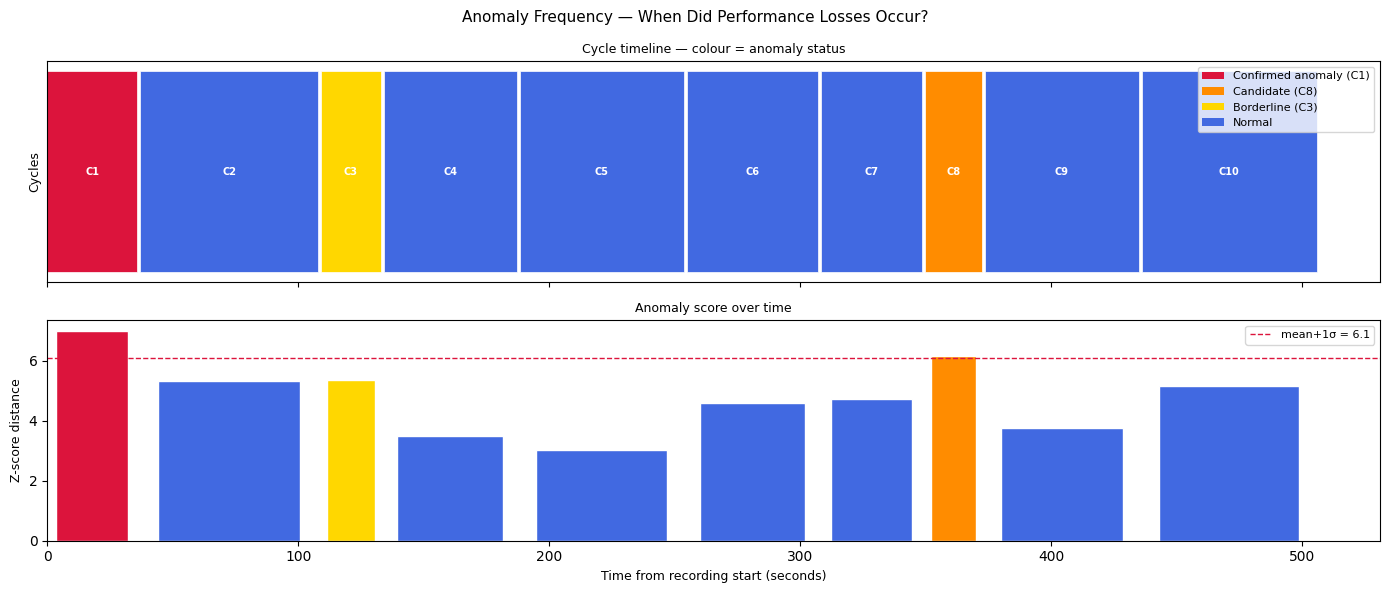

Saved: anomaly_frequency_timeline.png


In [27]:
# -----------------------------------------------------------------------------
# 7.3  TIMELINE VISUALISATION
# — Shows exactly when anomalous cycles occurred in the recording
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
fig.suptitle("Anomaly Frequency — When Did Performance Losses Occur?",
             fontsize=11)

# Panel 1 — cycle durations as a timeline
ax = axes[0]
status_colors = {
    "Confirmed":  "crimson",
    "Candidate":  "darkorange",
    "Borderline": "gold",
    "Normal":     "royalblue",
}
for _, row in cycle_timeline.iterrows():
    col = status_colors[row["status"]]
    ax.barh(0, row["duration_s"],
            left=row["elapsed_s"],
            height=0.5, color=col, edgecolor="white", linewidth=0.5)
    ax.text(row["elapsed_s"] + row["duration_s"] / 2, 0,
            f"C{int(row['cycle_id'])}",
            ha="center", va="center", fontsize=7,
            color="white", fontweight="bold")

from matplotlib.patches import Patch
legend_els = [
    Patch(facecolor="crimson",    label="Confirmed anomaly (C1)"),
    Patch(facecolor="darkorange", label="Candidate (C8)"),
    Patch(facecolor="gold",       label="Borderline (C3)"),
    Patch(facecolor="royalblue",  label="Normal"),
]
ax.legend(handles=legend_els, fontsize=8, loc="upper right")
ax.set_yticks([])
ax.set_ylabel("Cycles", fontsize=9)
ax.set_title("Cycle timeline — colour = anomaly status", fontsize=9)

# Panel 2 — z-score anomaly distance over time
ax = axes[1]
colors_bar = [status_colors[s] for s in cycle_timeline["status"]]
ax.bar(cycle_timeline["elapsed_s"] +
       cycle_timeline["duration_s"] / 2,
       cycle_timeline["zscore_dist"],
       width=cycle_timeline["duration_s"] * 0.8,
       color=colors_bar, edgecolor="white")

# Mark anomaly threshold (mean + 1 std)
thresh = cycle_timeline["zscore_dist"].mean() + \
         cycle_timeline["zscore_dist"].std()
ax.axhline(thresh, color="crimson", lw=1,
           linestyle="--", label=f"mean+1σ = {thresh:.1f}")
ax.set_xlabel("Time from recording start (seconds)", fontsize=9)
ax.set_ylabel("Z-score distance", fontsize=9)
ax.set_title("Anomaly score over time", fontsize=9)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("anomaly_frequency_timeline.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: anomaly_frequency_timeline.png")



In [28]:
# -----------------------------------------------------------------------------
# 7.4  PATTERN ANALYSIS — are anomalies clustered or spread out?
# -----------------------------------------------------------------------------

print("\n--- Anomaly Timing Pattern ---")
for _, row in cycle_timeline[cycle_timeline["status"] != "Normal"].iterrows():
    print(f"  C{int(row['cycle_id'])} ({row['status']:12s}) "
          f"at {row['elapsed_s']:.1f}s into recording "
          f"(~{row['elapsed_s']/60:.1f} min) "
          f"— {row['duration_s']:.1f}s duration")

# Check if anomalies cluster near start, middle, or end
print(f"\n  Total recording: {recording_mins:.1f} min")
print(f"  C1 occurred at : "
      f"{cycle_timeline[cycle_timeline.cycle_id==1]['elapsed_s'].values[0]:.1f}s "
      f"(first {cycle_timeline[cycle_timeline.cycle_id==1]['elapsed_s'].values[0]/recording_mins/60*100:.0f}% of recording)")
print(f"  C8 occurred at : "
      f"{cycle_timeline[cycle_timeline.cycle_id==8]['elapsed_s'].values[0]:.1f}s "
      f"(~{cycle_timeline[cycle_timeline.cycle_id==8]['elapsed_s'].values[0]/recording_mins/60*100:.0f}% of recording)")



--- Anomaly Timing Pattern ---
  C1 (Confirmed   ) at 0.0s into recording (~0.0 min) — 35.8s duration
  C3 (Borderline  ) at 109.1s into recording (~1.8 min) — 23.8s duration
  C8 (Candidate   ) at 349.7s into recording (~5.8 min) — 22.8s duration

  Total recording: 8.4 min
  C1 occurred at : 0.0s (first 0% of recording)
  C8 occurred at : 349.7s (~69% of recording)


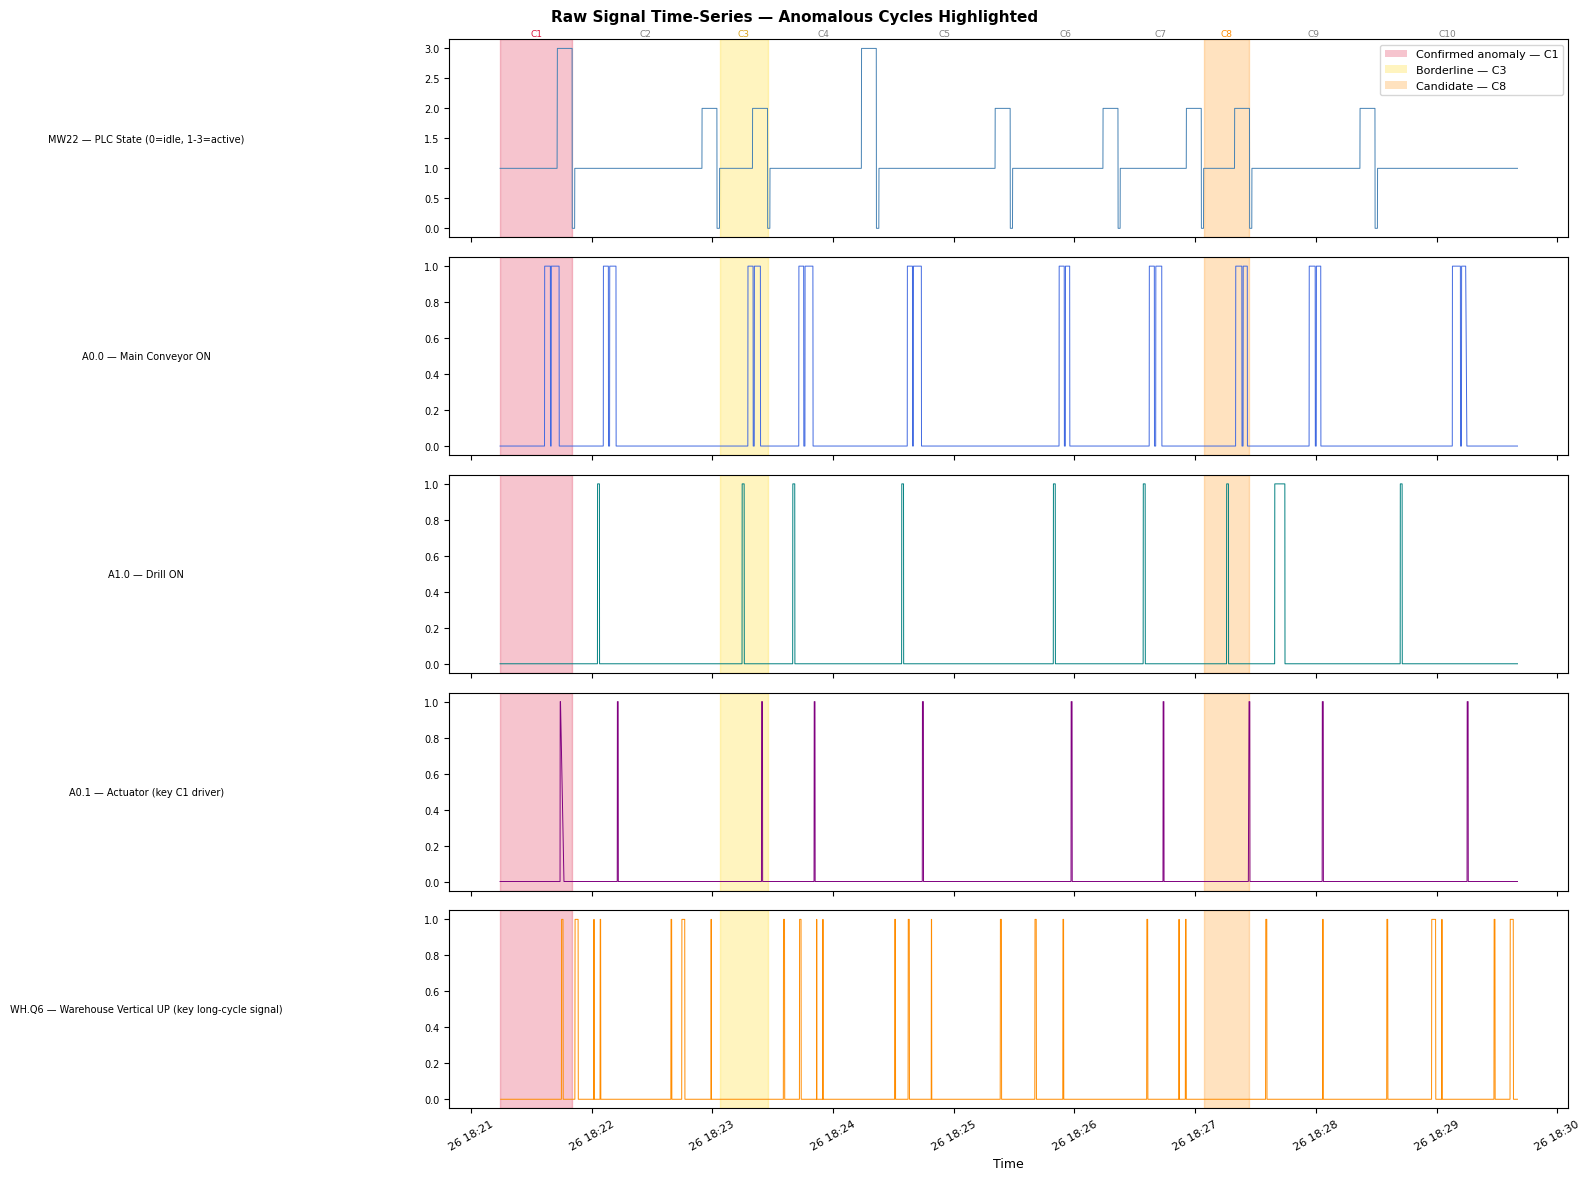

Saved: anomaly_timeseries_overlay.png


In [29]:
# =============================================================================
# 7.5  TIME-SERIES ANOMALY OVERLAY
# — Plot key raw signals across the full 8.5 min recording
# — Shade anomalous cycle windows directly on the signal
# — To show "when" anomalies occurred
# =============================================================================

fig, axes = plt.subplots(5, 1, figsize=(16, 12), sharex=True)
fig.suptitle("Raw Signal Time-Series — Anomalous Cycles Highlighted",
             fontsize=11, fontweight="bold")

# Signals to plot — one per panel, chosen to show different subsystems
signals = [
    ("MW22",  df_s,  "MW22 — PLC State (0=idle, 1-3=active)",  "steelblue"),
    ("A0.0",  df_s,  "A0.0 — Main Conveyor ON",                "royalblue"),
    ("A1.0",  df_s,  "A1.0 — Drill ON",                        "teal"),
    ("A0.1",  df_s,  "A0.1 — Actuator (key C1 driver)",        "purple"),
    ("WH.Q6_vertical_upward", df_work,
     "WH.Q6 — Warehouse Vertical UP (key long-cycle signal)",  "darkorange"),
]

# Anomaly window definitions from cycle_timeline
anomaly_windows = {
    "Confirmed (C1)":  ("crimson",    0.25,
                        cycle_timeline[cycle_timeline.cycle_id==1][["start","end"]].values[0]),
    "Borderline (C3)": ("gold",       0.25,
                        cycle_timeline[cycle_timeline.cycle_id==3][["start","end"]].values[0]),
    "Candidate (C8)":  ("darkorange", 0.25,
                        cycle_timeline[cycle_timeline.cycle_id==8][["start","end"]].values[0]),
}

for ax, (col, df, label, color) in zip(axes, signals):
    if col in df.columns:
        ts_col = "timestamp" if "timestamp" in df.columns else df.index
        ax.plot(df["timestamp"], df[col].astype(float),
                lw=0.7, color=color)

        # Shade anomalous cycle windows
        for status, (shade_col, alpha, (t_start, t_end)) in anomaly_windows.items():
            ax.axvspan(t_start, t_end,
                       color=shade_col, alpha=alpha, zorder=0)

        ax.set_ylabel(label, fontsize=7, rotation=0,
                      labelpad=200, va="center")
        ax.tick_params(axis="y", labelsize=7)
    else:
        ax.text(0.5, 0.5, f"{col} not found",
                transform=ax.transAxes, ha="center", fontsize=8)

# Add cycle ID labels on top panel
for _, row in cycle_timeline.iterrows():
    mid = row["start"] + pd.Timedelta(seconds=row["duration_s"] / 2)
    axes[0].text(mid, 3.2, f"C{int(row['cycle_id'])}",
                 ha="center", fontsize=6.5,
                 color="crimson" if row["status"] == "Confirmed"
                 else "darkorange" if row["status"] == "Candidate"
                 else "goldenrod" if row["status"] == "Borderline"
                 else "gray")

# Legend
from matplotlib.patches import Patch
legend_els = [
    Patch(facecolor="crimson",    alpha=0.25, label="Confirmed anomaly — C1"),
    Patch(facecolor="gold",       alpha=0.25, label="Borderline — C3"),
    Patch(facecolor="darkorange", alpha=0.25, label="Candidate — C8"),
]
axes[0].legend(handles=legend_els, fontsize=8, loc="upper right")

axes[-1].tick_params(axis="x", labelsize=8, rotation=30)
axes[-1].set_xlabel("Time", fontsize=9)

plt.tight_layout()
plt.savefig("anomaly_timeseries_overlay.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: anomaly_timeseries_overlay.png")

In [30]:
# OEE Performance Calculation
normal_cycles    = cycle_timeline[cycle_timeline["status"] == "Normal"]
ideal_cycle_time = normal_cycles["duration_s"].min()

units_produced   = len(cycle_timeline)
total_operating  = cycle_timeline["duration_s"].sum()
seconds_lost     = cycle_timeline[cycle_timeline["status"] != "Normal"]["duration_s"].sum()

# Cycle-based OEE
performance_oee  = (ideal_cycle_time * units_produced) / total_operating * 100

# Time-based OEE (Paper 2 style)
performance_time = (1 - seconds_lost / total_operating) * 100

print(f"Ideal cycle time (min normal) : {ideal_cycle_time:.1f}s")
print(f"Total cycles                  : {units_produced}")
print(f"Total operating time          : {total_operating:.1f}s")
print(f"Seconds in anomalous cycles   : {seconds_lost:.1f}s")
print(f"Anomaly time fraction         : {seconds_lost/total_operating*100:.1f}%")
print(f"OEE Performance (cycle-based) : {performance_oee:.1f}%")
print(f"OEE Performance (time-based)  : {performance_time:.1f}%")

Ideal cycle time (min normal) : 40.2s
Total cycles                  : 10
Total operating time          : 494.3s
Seconds in anomalous cycles   : 82.4s
Anomaly time fraction         : 16.7%
OEE Performance (cycle-based) : 81.4%
OEE Performance (time-based)  : 83.3%


Trying to answer to professor's final question: Anomalous cycles occurred 3 times out of 10, a rate of 30% of cycles, approximately once every 2.8 minutes. <br>
In time terms, 82.4 seconds out of 494 seconds — 16.7% of operating time — was spent in anomalous cycles.